# Project 6 — Module 7: Aprendizaje de Máquina No Supervisado
## Lección 4: Modeling — PCA, t-SNE, KMeans, DBSCAN, Hierarchical

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 4 — Modeling |
| **Module** | 7 — Aprendizaje de Máquina No Supervisado (Alkemy Bootcamp) |
| **Dataset** | Customer Segmentation — Kaggle (kaushiksuresh147) |
| **Date** | 2026-03 |

---

> **Executive Summary:**
> This notebook applies PCA and t-SNE for dimensionality reduction, and KMeans, DBSCAN,
> and Hierarchical clustering to the preprocessed customer feature matrix.
> Results are visualized in 2D. Cluster labels and embeddings are saved to data/final/
> for evaluation in notebook 05.

## Table of Contents

1. [CRISP-DM Phase 4 — Modeling](#1-crisp-dm-phase-4--modeling)
2. [Environment Setup](#2-environment-setup)
3. [Load Processed Data](#3-load-processed-data)
4. [Dimensionality Reduction — PCA](#4-dimensionality-reduction--pca)
5. [Dimensionality Reduction — t-SNE](#5-dimensionality-reduction--t-sne)
6. [KMeans — Elbow Method & Clustering](#6-kmeans--elbow-method--clustering)
7. [DBSCAN Clustering](#7-dbscan-clustering)
8. [Hierarchical Clustering & Dendrogram](#8-hierarchical-clustering--dendrogram)
9. [Save Labels & Embeddings](#9-save-labels--embeddings)
10. [LEAN Filter — Waste Elimination Review](#10-lean-filter--waste-elimination-review)
11. [Decisions Log — Lesson 4](#11-decisions-log--lesson-4)
12. [Next Steps — Lesson 5 Preview](#12-next-steps--lesson-5-preview)

## 1. CRISP-DM Phase 4 — Modeling

**Goal:** Apply dimensionality reduction and clustering algorithms to discover
behavioral customer segments. Each algorithm is applied and visualized independently
to enable a fair comparison in notebook 05 (Evaluation).

**ICI perspective:** Clustering is analogous to stratifying a production process —
identifying natural strata that require different interventions rather than
applying a uniform response to all units.

## 2. Environment Setup

In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# Python utilities
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Cluster evaluation
from sklearn.metrics import silhouette_score

# Hierarchical dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PROCESSED  = Path('../data/processed')
DATA_FINAL      = Path('../data/final')
REPORTS_FIGURES = Path('../reports/figures')
DATA_FINAL.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


## 3. Load Processed Data

In [2]:
# Load scaled feature matrix produced in notebook 03
X = np.load(DATA_PROCESSED / 'X_scaled.npy')
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (6147, 23)


## 4. Dimensionality Reduction — PCA

PCA finds the directions of maximum variance and projects all observations onto
those axes. Used here for two purposes:
1. **Visualization** — 2D scatter plot of the customer feature space
2. **Input to t-SNE** — reduces noise and improves t-SNE stability on high-dim data

**Personal perspective:** PC1 captures the dominant behavioral axis — analogous to the
principal direction of variation in a multivariate control chart.

In [3]:
# Fit PCA with 2 components for visualization
pca_2d    = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca     = pca_2d.fit_transform(X)

print(f'Explained variance ratio : {pca_2d.explained_variance_ratio_.round(3)}')
print(f'Total variance explained : {pca_2d.explained_variance_ratio_.sum():.1%}')

Explained variance ratio : [0.131 0.081]
Total variance explained : 21.3%


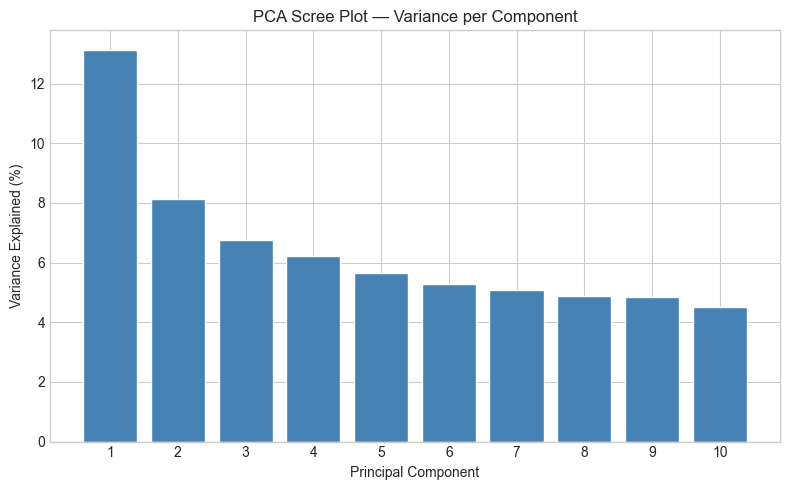

In [4]:
# Scree plot — how much variance each component captures
n_components_scree = min(10, X.shape[1])
pca_scree          = PCA(n_components=n_components_scree, random_state=RANDOM_STATE)
pca_scree.fit(X)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    range(1, n_components_scree + 1),
    pca_scree.explained_variance_ratio_ * 100,
    color='steelblue',
    edgecolor='white'
)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA Scree Plot — Variance per Component')
ax.set_xticks(range(1, n_components_scree + 1))
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Dimensionality Reduction — t-SNE

t-SNE is a non-linear technique that preserves local neighborhood structure.
Unlike PCA, it is optimized for 2D visualization and reveals cluster separation
that linear methods may miss.

> **Important:** t-SNE distances between clusters are NOT interpretable.
> Only the presence of distinct groups matters — not how far apart they appear.

Applied on PCA output (not full matrix) for speed and stability.

t-SNE output shape: (6147, 2)


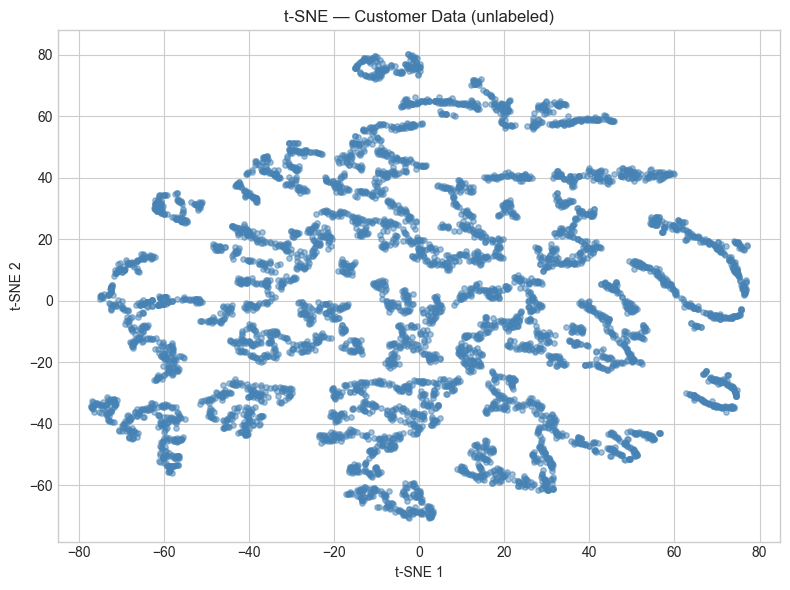

In [5]:
# Apply t-SNE on PCA-reduced data — standard practice for high-dim datasets
tsne   = TSNE(n_components=2, perplexity=30.0, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_pca)

print(f't-SNE output shape: {X_tsne.shape}')

# Visualize unlabeled structure before clustering
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=15, color='steelblue')
ax.set_title('t-SNE — Customer Data (unlabeled)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'tsne_unlabeled.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. KMeans — Elbow Method & Clustering

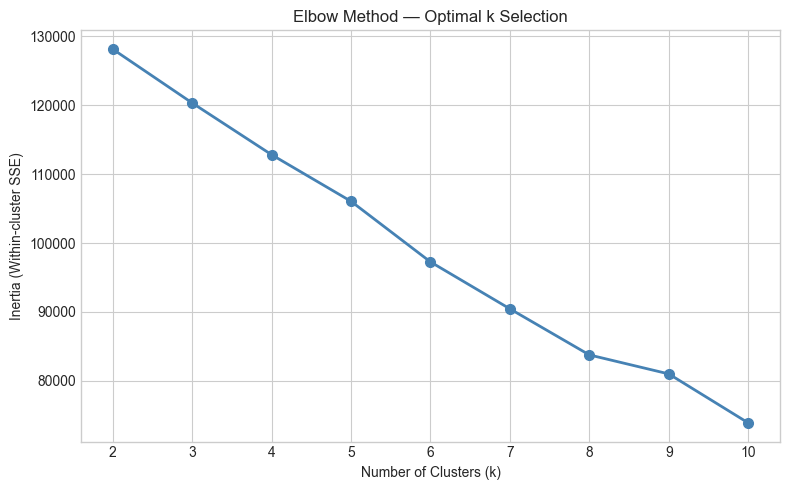

In [6]:
# Elbow method — compute inertia for k=2 to 10
k_range    = range(2, 11)
inertias   = {
    k: KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X).inertia_
    for k in k_range
}

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(inertias.keys()), list(inertias.values()),
        marker='o', color='steelblue', linewidth=2, markersize=7)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-cluster SSE)')
ax.set_title('Elbow Method — Optimal k Selection')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

KMeans silhouette score (k=4): 0.154


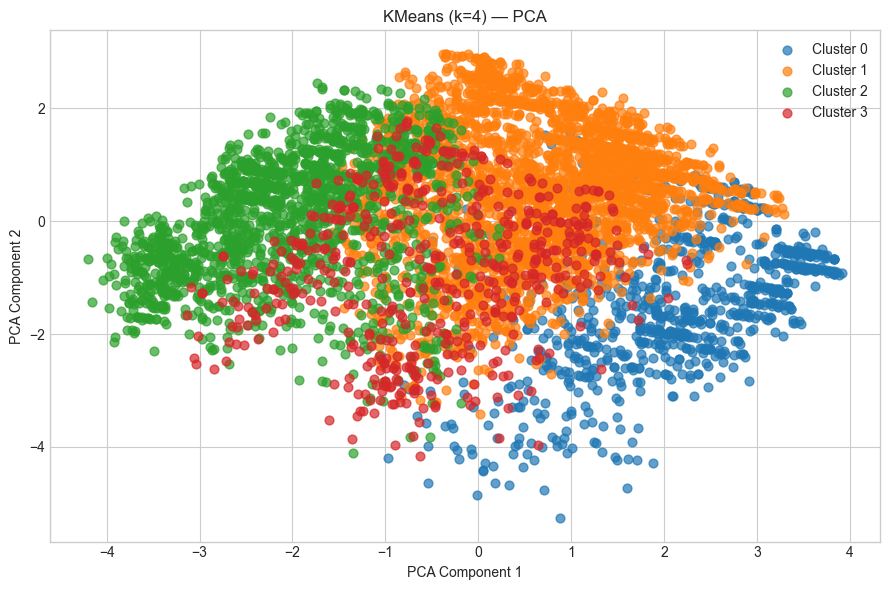

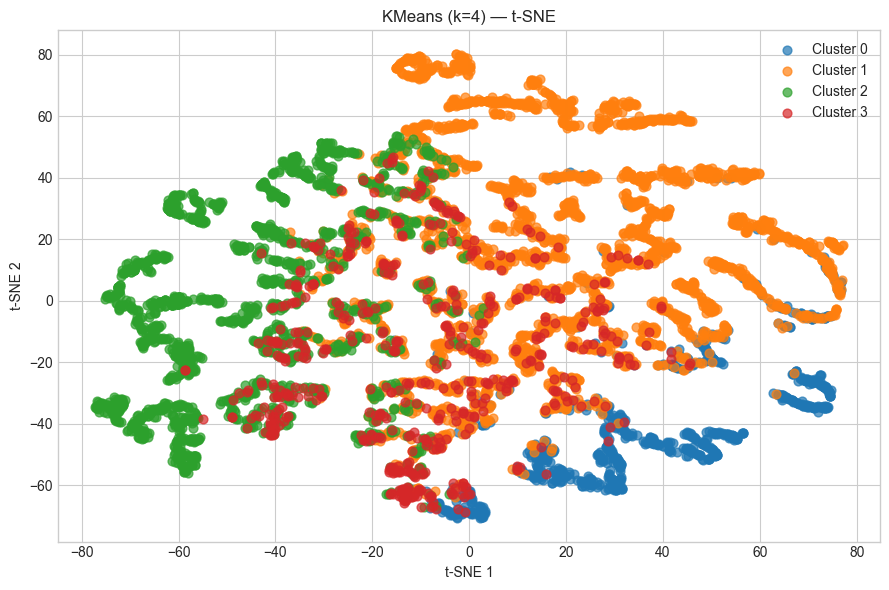

In [7]:
# Set optimal k after visual inspection of elbow curve above
OPTIMAL_K = 4  # ⚠️ Update based on elbow curve observation

km              = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
km_labels       = km.fit_predict(X)
km_silhouette   = silhouette_score(X, km_labels)

print(f'KMeans silhouette score (k={OPTIMAL_K}): {km_silhouette:.3f}')

# Visualize on PCA
palette = sns.color_palette('tab10', n_colors=OPTIMAL_K)
fig, ax = plt.subplots(figsize=(9, 6))
for i in range(OPTIMAL_K):
    mask = km_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {i}', alpha=0.7, s=40, color=palette[i])
ax.set_title(f'KMeans (k={OPTIMAL_K}) — PCA')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualize on t-SNE
fig, ax = plt.subplots(figsize=(9, 6))
for i in range(OPTIMAL_K):
    mask = km_labels == i
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=f'Cluster {i}', alpha=0.7, s=40, color=palette[i])
ax.set_title(f'KMeans (k={OPTIMAL_K}) — t-SNE')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'kmeans_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. DBSCAN Clustering

DBSCAN does not require specifying k — it discovers clusters based on density.
Points in low-density regions are labeled as noise (-1).
Applied on PCA-reduced data to mitigate the curse of dimensionality.

DBSCAN clusters found : 1
Noise points          : 1 (0.0%)
DBSCAN silhouette     : N/A (fewer than 2 clusters found)


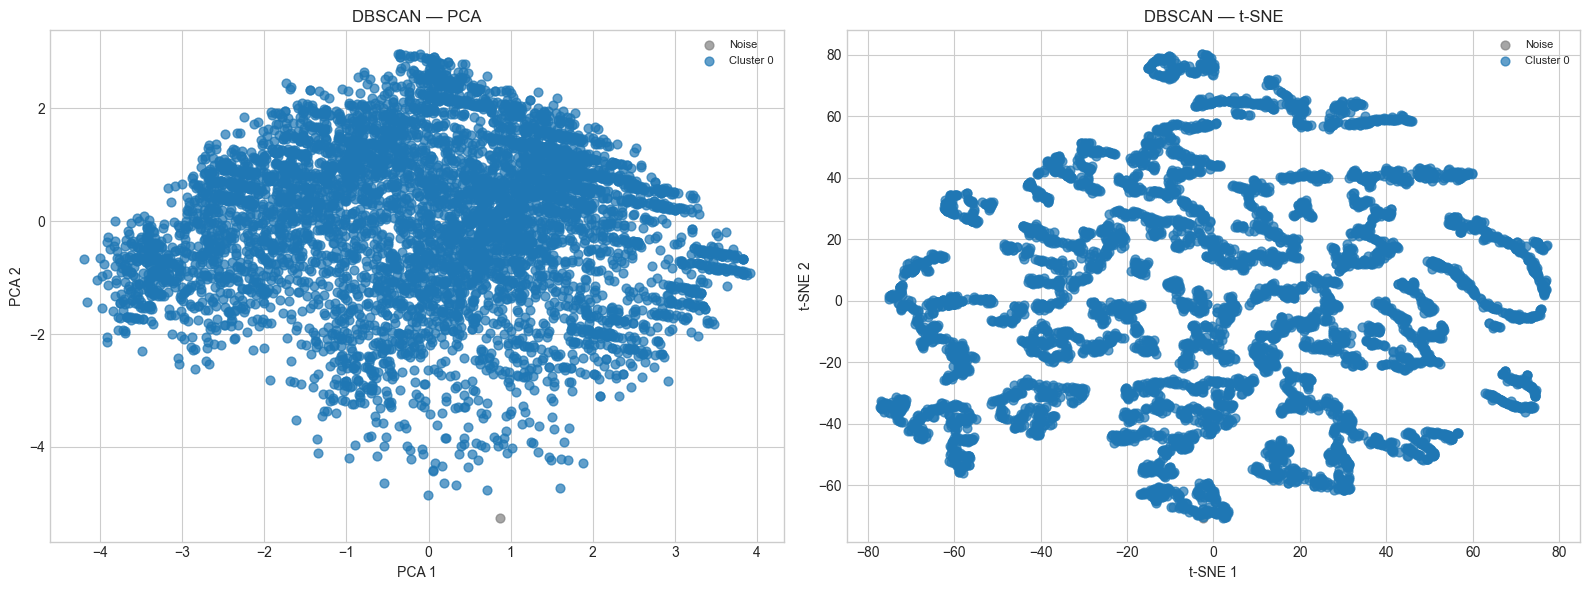

In [8]:
# Applied on PCA-reduced data — eps calibration is unreliable on high-dim full matrix
db          = DBSCAN(eps=0.5, min_samples=5)
db_labels   = db.fit_predict(X_pca)

n_clusters  = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise     = (db_labels == -1).sum()

print(f'DBSCAN clusters found : {n_clusters}')
print(f'Noise points          : {n_noise} ({n_noise/len(db_labels):.1%})')

# Silhouette only meaningful with 2+ clusters
if n_clusters > 1:
    db_silhouette = silhouette_score(X_pca, db_labels)
    print(f'DBSCAN silhouette     : {db_silhouette:.3f}')
else:
    db_silhouette = None
    print('DBSCAN silhouette     : N/A (fewer than 2 clusters found)')

# Visualize — noise points rendered in gray
unique_labels = sorted(set(db_labels))
palette_db    = sns.color_palette('tab10', n_colors=max(n_clusters, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, X_2d, method in zip(axes, [X_pca, X_tsne], ['PCA', 't-SNE']):
    color_idx = 0  # Separate counter for valid clusters only
    for label in unique_labels:
        mask  = db_labels == label
        if label == -1:
            color = 'gray'
            lname = 'Noise'
        else:
            color = palette_db[color_idx]
            lname = f'Cluster {label}'
            color_idx += 1
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=lname, alpha=0.7, s=40, color=color)
    ax.set_title(f'DBSCAN — {method}')
    ax.set_xlabel(f'{method} 1')
    ax.set_ylabel(f'{method} 2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'dbscan_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Hierarchical Clustering & Dendrogram

The dendrogram reveals natural cluster structure before specifying k.
Large vertical gaps between merges indicate strong cluster boundaries.
Ward linkage minimizes within-cluster variance — consistent with KMeans objective.

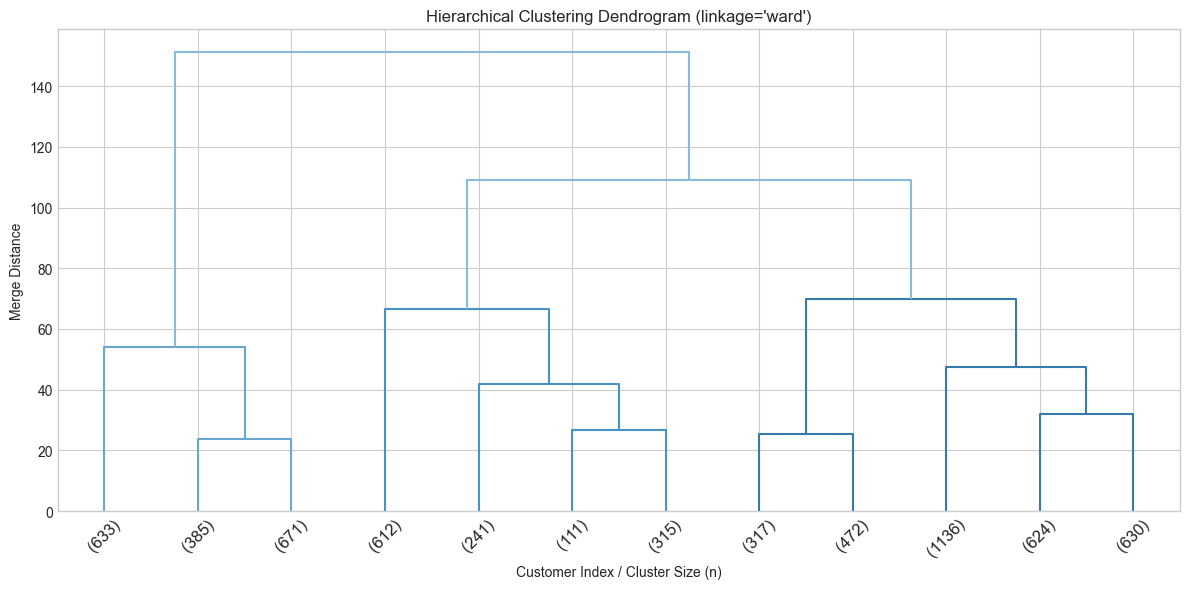

In [9]:
# Dendrogram on PCA-reduced data — avoids memory issues with large n
linked = linkage(X_pca, method='ward')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode='lastp',  # Show only last 12 merges for readability
    p=12,
    leaf_rotation=45,
    ax=ax
)
ax.set_title("Hierarchical Clustering Dendrogram (linkage='ward')")
ax.set_xlabel('Customer Index / Cluster Size (n)')
ax.set_ylabel('Merge Distance')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'dendrogram_ward.png', dpi=150, bbox_inches='tight')
plt.show()

Hierarchical silhouette score (k=4): 0.088


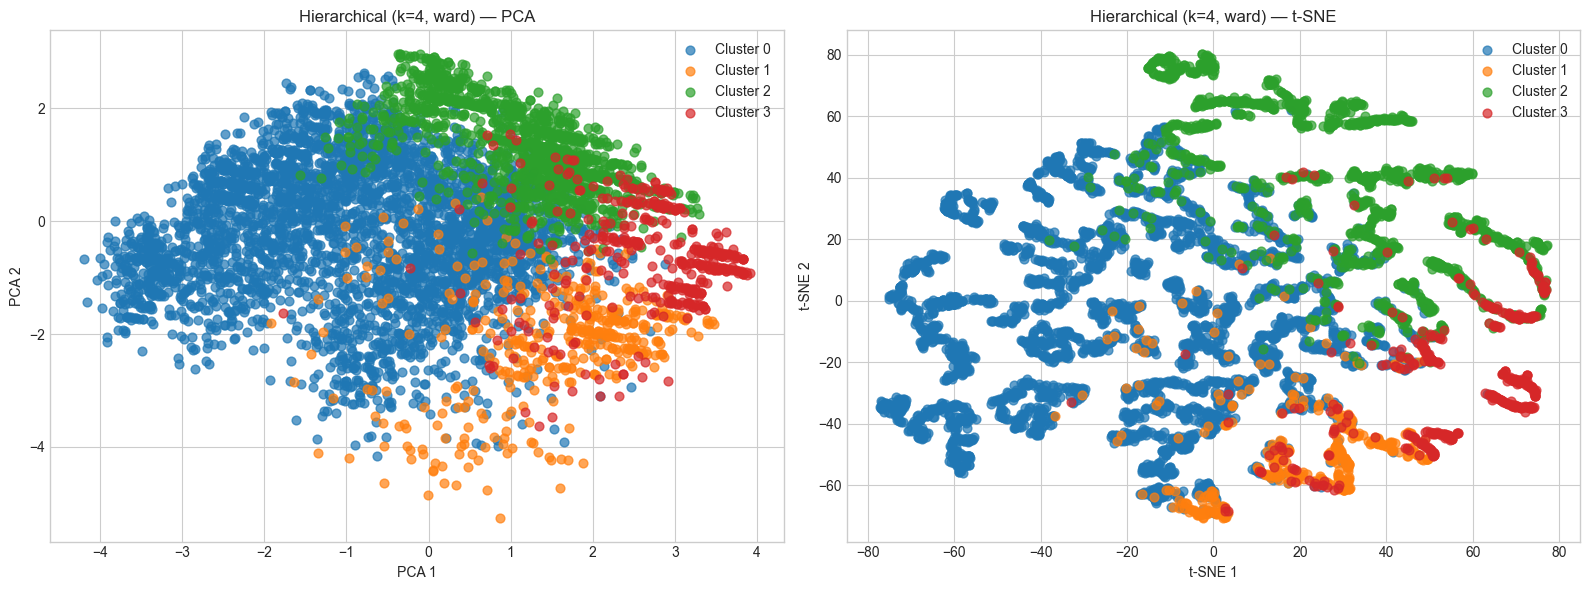

In [10]:
# Fit Agglomerative Clustering with same k as KMeans for fair comparison
hc          = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hc_labels   = hc.fit_predict(X)
hc_silhouette = silhouette_score(X, hc_labels)

print(f'Hierarchical silhouette score (k={OPTIMAL_K}): {hc_silhouette:.3f}')

# Visualize on PCA and t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, X_2d, method in zip(axes, [X_pca, X_tsne], ['PCA', 't-SNE']):
    for i in range(OPTIMAL_K):
        mask = hc_labels == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=f'Cluster {i}', alpha=0.7, s=40, color=palette[i])
    ax.set_title(f'Hierarchical (k={OPTIMAL_K}, ward) — {method}')
    ax.set_xlabel(f'{method} 1')
    ax.set_ylabel(f'{method} 2')
    ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'hierarchical_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Labels & Embeddings

In [11]:
# Save cluster labels for all three algorithms — used in notebook 05 (Evaluation)
labels_df = pd.DataFrame({
    'kmeans':       km_labels,
    'dbscan':       db_labels,
    'hierarchical': hc_labels,
})
labels_df.to_csv(DATA_FINAL / 'cluster_labels.csv', index=False)

# Save 2D embeddings — used for visualization in notebook 05
np.save(DATA_FINAL / 'X_pca.npy',  X_pca)
np.save(DATA_FINAL / 'X_tsne.npy', X_tsne)

print(f'Saved: cluster_labels.csv — {labels_df.shape}')
print(f'Saved: X_pca.npy  — {X_pca.shape}')
print(f'Saved: X_tsne.npy — {X_tsne.shape}')
print(f'Path : {DATA_FINAL}')

Saved: cluster_labels.csv — (6147, 3)
Saved: X_pca.npy  — (6147, 2)
Saved: X_tsne.npy — (6147, 2)
Path : ..\data\final


## 10. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Does running 3 algorithms add business value? | ✅ Comparison justifies algorithm choice to stakeholder | Proceed |
| Is t-SNE on PCA necessary? | ✅ t-SNE on high-dim full matrix is unstable — PCA first is standard practice | Proceed |
| Is exhaustive DBSCAN eps tuning needed now? | ⚠️ Default eps sufficient for comparison — tune in notebook 05 if DBSCAN wins | Defer |
| Are all visualizations decision-relevant? | ✅ Each plot answers a specific business question from notebook 01 | Proceed |
| Is saving X_pca and X_tsne necessary? | ✅ Avoids recomputing expensive t-SNE in notebook 05 | Proceed |

## 11. Decisions Log — Lesson 4

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | PCA before t-SNE | Standard practice — reduces noise and improves t-SNE stability | t-SNE on full matrix | ✅ |
| 2 | DBSCAN on PCA-reduced X | Mitigates curse of dimensionality — eps calibration unreliable on high-dim data | DBSCAN on full X | ✅ |
| 3 | Ward linkage for hierarchical | Minimizes within-cluster variance — consistent objective with KMeans for fair comparison | Complete linkage | ✅ |
| 4 | OPTIMAL_K = 4 placeholder | Update from visual inspection of elbow curve — do not hardcode without evidence | Fixed k | ⚠️ Update after running |
| 5 | n_init=10 for KMeans | Multiple restarts prevent poor local minima — especially important for small datasets | n_init=1 | ✅ |

## 12. Next Steps — Lesson 5 Preview

- Load `cluster_labels.csv`, `X_scaled.npy`, `X_pca.npy`, `X_tsne.npy`
- Compare silhouette scores across all three algorithms
- Profile each cluster of the best algorithm (mean feature values)
- Map cluster profiles to commercial personas
- Generate marketing recommendations per segment

---

**← Previous:** [03 — Data Preparation](./03_data_preparation.ipynb)  
**Next →** [05 — Evaluation](./05_evaluation.ipynb)